# PSDCodec Deployment Example

This notebook demonstrates the deployment boundary using the trained `baseline_psdcodec` artifacts already present in the repository. The sensing-node encoder runs through the exported ONNX graph, while the cloud-side decoder is restored from the best checkpoint.

Run it with the repository `.venv` kernel so both `torch` and `onnxruntime` are available.


## What This Notebook Shows

1. Load the exported runtime assets and encoder ONNX file.
2. Load one real PSD frame from `data/raw/campaigns`.
3. Encode, quantize, entropy-code, packetize, decode, and reconstruct the frame.
4. Plot the original PSD, the preprocessing-only reconstruction, and the final reconstruction.


In [1]:
import os
import sys
import tempfile
from pathlib import Path

candidate_roots = [Path.cwd().resolve(), Path.cwd().resolve().parent]
project_root = next(root for root in candidate_roots if (root / "src").exists())
src_root = project_root / "src"
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "psdcodec_mpl"))

project_root


PosixPath('/home/marti/Code/PSDCodec')

In [ ]:
import importlib.util
import sys

missing_packages = [
    package_name
    for package_name in ("torch", "onnxruntime")
    if importlib.util.find_spec(package_name) is None
]
if missing_packages:
    raise RuntimeError(
        "Notebook dependencies are missing from the active kernel: "
        f"{missing_packages}. Run this notebook with the repository .venv kernel. "
        f"Current executable: {sys.executable}"
    )


In [3]:
import matplotlib.pyplot as plt
import numpy as np

from interfaces.deployment import create_deployment_service, load_campaign_frame_sample


In [4]:
export_dir = project_root / "models" / "exports" / "baseline_psdcodec"
service, artifacts = create_deployment_service(export_dir)
sample = load_campaign_frame_sample(artifacts, frame_index=0)

sample_summary = {
    "campaign_label": sample.campaign_label,
    "node_label": sample.node_label,
    "sequence_id": sample.sequence_id,
    "timestamp_ms": sample.timestamp_ms,
    "original_bin_count": sample.frame.size,
    "reduced_bin_count": artifacts.runtime_config.preprocessing.resolve_reduced_bin_count(
        sample.frame.size,
    ),
    "onnx_path": str(artifacts.onnx_path),
    "checkpoint_path": str(artifacts.checkpoint_path),
}
sample_summary


{'campaign_label': 'ANTENNA_sweep',
 'node_label': 'Node1',
 'sequence_id': 'ANTENNA_sweep/Node1',
 'timestamp_ms': 1773765849126,
 'original_bin_count': 4096,
 'reduced_bin_count': 128,
 'onnx_path': '/home/marti/Code/PSDCodec/models/exports/baseline_psdcodec/encoder.onnx',
 'checkpoint_path': '/home/marti/Code/PSDCodec/models/checkpoints/baseline_psdcodec/best.pt'}

In [5]:
evaluation = service.evaluate_frame(
    sample.frame,
    noise_floor=sample.noise_floor,
    frequency_grid_hz=sample.frequency_grid_hz,
)
decoded = service.decode_packet(evaluation.encode_result.packet_bytes)
assert np.allclose(decoded.reconstructed_frame, evaluation.encode_result.reconstructed_frame)

result_summary = {
    "packet_bytes": len(evaluation.encode_result.packet_bytes),
    "operational_bit_count": evaluation.encode_result.operational_bit_count,
    "rate_proxy_bit_count": evaluation.encode_result.rate_proxy_bit_count,
    "latent_vector_count": evaluation.encode_result.packet.latent_vector_count,
    "side_information_bit_count": evaluation.encode_result.packet.side_information_bit_count,
    "index_bit_count": evaluation.encode_result.packet.index_bit_count,
    "psd_distortion": evaluation.distortion.psd_distortion,
    "preprocessing_distortion": evaluation.distortion.preprocessing_distortion,
    "codec_distortion": evaluation.distortion.codec_distortion,
}
result_summary


{'packet_bytes': 79,
 'operational_bit_count': 398,
 'rate_proxy_bit_count': 397.1201995200725,
 'latent_vector_count': 32,
 'side_information_bit_count': 176,
 'index_bit_count': 222,
 'psd_distortion': 0.6590334770574422,
 'preprocessing_distortion': 1.2533417577963475,
 'codec_distortion': 0.603808678254882}

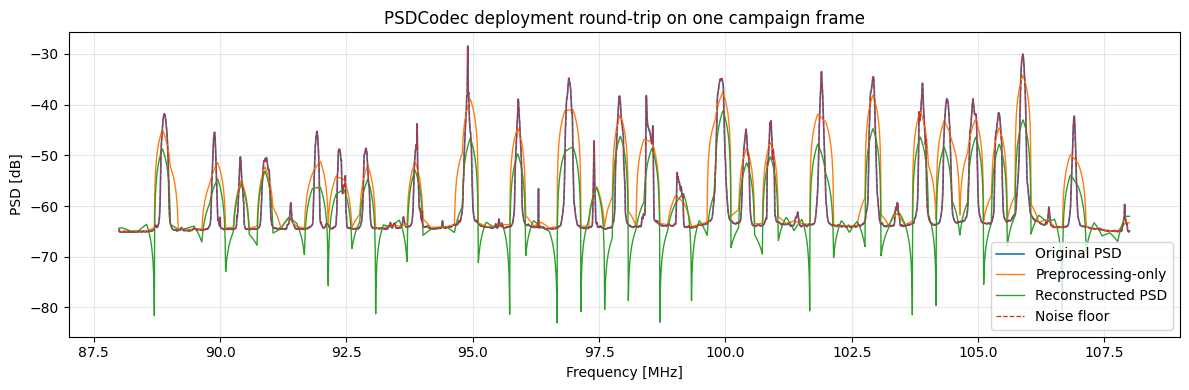

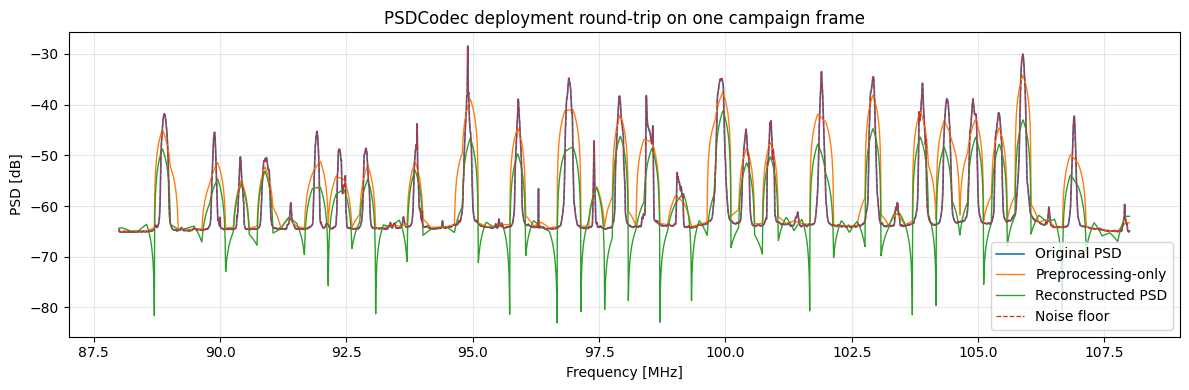

In [6]:
def to_db(values: np.ndarray) -> np.ndarray:
    """Convert linear power to dB for visualization."""
    return 10.0 * np.log10(np.clip(values, 1.0e-12, None))


frequency_mhz = sample.frequency_grid_hz / 1.0e6
original_db = to_db(sample.frame)
preprocessing_only_db = to_db(evaluation.encode_result.preprocessing_only_frame)
reconstructed_db = to_db(evaluation.encode_result.reconstructed_frame)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(frequency_mhz, original_db, label="Original PSD", linewidth=1.2)
ax.plot(frequency_mhz, preprocessing_only_db, label="Preprocessing-only", linewidth=1.0)
ax.plot(frequency_mhz, reconstructed_db, label="Reconstructed PSD", linewidth=1.0)
if sample.noise_floor is not None:
    ax.plot(
        frequency_mhz,
        to_db(sample.noise_floor),
        label="Noise floor",
        linewidth=0.9,
        linestyle="--",
    )
ax.set_title("PSDCodec deployment round-trip on one campaign frame")
ax.set_xlabel("Frequency [MHz]")
ax.set_ylabel("PSD [dB]")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig


## Interpretation

The packet and distortion summaries above reflect the full operational codec, not only a neural-network forward pass. The encoder side of the learned model is executed through ONNX Runtime, while side-information handling, nearest-codeword assignment, entropy coding, and reconstruction remain explicit software components.
